# Pooling in CNN

Pooling is a technique used in Convolutional Neural Networks (CNNs)
to reduce the spatial dimensions of feature maps.

Pooling helps the CNN:

- Reduce the size of feature maps
- Reduce computational cost
- Reduce the number of parameters in later layers
- Keep important features
- Make the model more efficient

The most commonly used pooling method is **Max Pooling**.

## 1. Why Do We Need Pooling?

After convolution, we get feature maps.

For example:

    8 × 8 × 32

This means:

- Height = 8
- Width = 8
- Channels/Feature Maps = 32

A large feature map contains a lot of information.

Pooling reduces the height and width while keeping the important
information.

For example:

    8 × 8 × 32

can become:

    4 × 4 × 32

Notice that the number of channels remains the same.

## 2. Max Pooling

Max Pooling selects the **maximum value** from a small region.

The most common configuration is:

- Pool size = 2 × 2
- Stride = 2

Example:

    1  5
    3  2

The maximum value is:

    5

Therefore, the 2 × 2 region becomes a single value: 5.

In [7]:
import numpy as np

region = np.array([
    [1, 5],
    [3, 2]
])

max_value = np.max(region)

print("Region:")
print(region)

print("\nMaximum value:", max_value)

Region:
[[1 5]
 [3 2]]

Maximum value: 5


In [8]:
feature_map = np.array([
    [1, 3, 2, 4],
    [5, 6, 1, 2],
    [7, 2, 8, 3],
    [4, 1, 5, 9]
])

pooled = np.array([
    [np.max(feature_map[0:2, 0:2]),
     np.max(feature_map[0:2, 2:4])],

    [np.max(feature_map[2:4, 0:2]),
     np.max(feature_map[2:4, 2:4])]
])

print("Original Feature Map:")
print(feature_map)

print("\nPooled Feature Map:")
print(pooled)

Original Feature Map:
[[1 3 2 4]
 [5 6 1 2]
 [7 2 8 3]
 [4 1 5 9]]

Pooled Feature Map:
[[6 4]
 [7 9]]


## 4. MaxPooling2D in TensorFlow

TensorFlow/Keras provides `MaxPooling2D()` for performing
max pooling.

Basic syntax:

```python
tf.keras.layers.MaxPooling2D(
    pool_size=(2, 2),
    strides=(2, 2)
)

import tensorflow as tf

pool = tf.keras.layers.MaxPooling2D(
    pool_size=(2, 2),
    strides=(2, 2)
)

feature_map = tf.random.normal((1, 64, 64, 32))

pooled_output = pool(feature_map)

print("Input shape :", feature_map.shape)## 5. What Happens to the Channels?

This is very important.

Suppose the feature map is:

    64 × 64 × 32

After Max Pooling:

    32 × 32 × 32

Only the height and width decrease.

The number of channels remains the same.

Why?

Because pooling is applied independently to each feature map.

So:

    32 feature maps

remain:

    32 feature maps

but each feature map becomes smaller.
print("Output shape:", pooled_output.shape)

## 6. Average Pooling

Average Pooling is similar to Max Pooling.

The difference is:

### Max Pooling

Selects the maximum value.

    1  5
    3  2

Maximum = 5

### Average Pooling

Calculates the average.

    1  5
    3  2

Average = (1 + 5 + 3 + 2) / 4

Average = 2.75

In [9]:
import tensorflow as tf
avg_pool = tf.keras.layers.AveragePooling2D(
    pool_size=(2, 2),
    strides=(2, 2)
)

feature_map = tf.random.normal((1, 64, 64, 32))

avg_output = avg_pool(feature_map)

print("Input shape :", feature_map.shape)
print("Output shape:", avg_output.shape)

Input shape : (1, 64, 64, 32)
Output shape: (1, 32, 32, 32)


In [10]:
model = tf.keras.Sequential([
    
    tf.keras.layers.Input(shape=(128, 128, 3)),
    
    tf.keras.layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        padding="same",
        activation="relu"
    ),
    
    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2)
    ),
    
    tf.keras.layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        padding="same",
        activation="relu"
    ),
    
    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2)
    )
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,392 (75.75 KB)

 Trainable params: 19,392 (75.75 KB)

 Non-trainable params: 0 (0.00 B)

## 10. Visualizing Pooling

Let's create a simple feature map and visualize how
Max Pooling reduces its spatial dimensions.

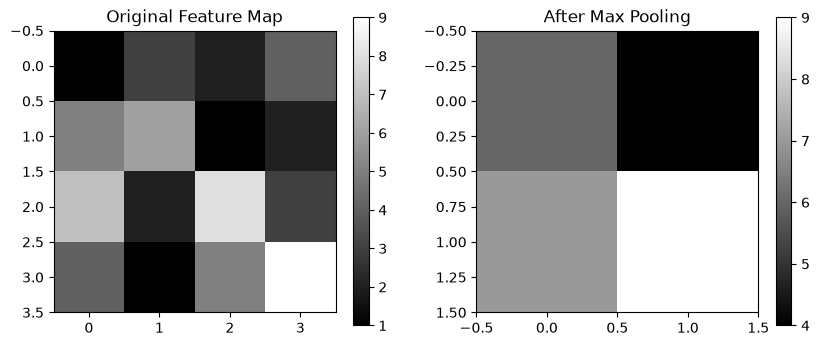

In [11]:
import matplotlib.pyplot as plt

feature_map = np.array([
    [1, 3, 2, 4],
    [5, 6, 1, 2],
    [7, 2, 8, 3],
    [4, 1, 5, 9]
])

pooled = np.array([
    [6, 4],
    [7, 9]
])

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(feature_map, cmap="gray")
plt.title("Original Feature Map")
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(pooled, cmap="gray")
plt.title("After Max Pooling")
plt.colorbar()

plt.show()